## Contenido
- Comenzando con PyTorch  
- Carga y procesamiento de datos  
- Construcción de modelos  
- Función de pérdida y optimizador  
- Entrenamiento y evaluación

## Descripción general

El aprendizaje profundo (deep learning) es un campo del aprendizaje automático que utiliza redes neuronales masivas, grandes volúmenes de datos y computación acelerada en GPUs. Muchos de los avances recientes en inteligencia artificial se deben al poder del aprendizaje profundo. Esta revolución ya está impactando una amplia gama de industrias con aplicaciones como asistentes de voz personales, imágenes médicas, vehículos automatizados, inteligencia artificial en videojuegos y mucho más.

En este cuaderno, cubriré los conceptos detrás del aprendizaje profundo y cómo construir modelos de deep learning utilizando PyTorch. Al finalizar el cuaderno, podrás definir y entrenar tus propios modelos de aprendizaje profundo de vanguardia.


## ¿Qué es el Machine Learning?

El aprendizaje automático (Machine Learning o ML) es una subrama de la inteligencia artificial que utiliza algoritmos y técnicas estadísticas para realizar tareas sin necesidad de instrucciones explícitas. En su lugar, se basa en los patrones estadísticos subyacentes presentes en los datos.



## ¿Qué es CUDA?

CUDA es un marco de trabajo desarrollado por NVIDIA que nos permite utilizar la Computación de Propósito General en Unidades de Procesamiento Gráfico (GPGPU). Es un framework ampliamente utilizado, escrito en C++, que nos permite crear programas de propósito general que se ejecutan en GPUs.  
Casi todos los frameworks de aprendizaje profundo aprovechan CUDA para ejecutar instrucciones en las tarjetas gráficas (GPUs).


## PyTorch

[PyTorch](https://pytorch.org) es un framework de código abierto en Python desarrollado por el [equipo de Facebook AI Research](https://ai.facebook.com/) para crear redes neuronales profundas.  

PyTorch puede considerarse una extensión de NumPy que incluye clases y herramientas prácticas para definir redes neuronales y realizar cálculos acelerados utilizando GPUs.  

Está diseñado con una filosofía *Python-first*, lo que significa que sigue las convenciones e ideas propias de Python y se integra perfectamente con los paquetes más populares del ecosistema Python.


## ¿Qué es una red neuronal?

En resumen, una red neuronal es un algoritmo que aprende la relación entre las variables de entrada y sus variables objetivo asociadas.


## Comenzando con PyTorch

### Verificando la instalación

Asegurémonos de que la instalación sea correcta importando PyTorch en Python:


In [1]:
# import PyTorch
import torch
# import torchvision
import torchvision

# get PyTorch version
print(torch.__version__)
# get torchvision version
print(torchvision.__version__)

1.5.0
0.6.0a0+82fd1c8


In [2]:
# checking if cuda is available
torch.cuda.is_available()

True

In [ ]:
# obtener el número de dispositivos CUDA/GPU
torch.cuda.device_count()

1

In [ ]:
# obtener el id del dispositivo CUDA/GPU
torch.cuda.current_device()

0

In [ ]:
# obtener el nombre del dispositivo CUDA/GPU
torch.cuda.get_device_name(0)

'Tesla P100-PCIE-16GB'

Los tensores son contenedores de datos y representan una generalización de los vectores y las matrices.  

Un **vector** es un tensor de primer orden, ya que solo tiene un eje, y se representa como `[x1, x2, x3, ...]`.  

Una **matriz** es un tensor de segundo orden, ya que tiene dos ejes, y se representa como `[[x11, x12, x13, ...], [x21, x22, x23, ...]]`.  

Por otro lado, un **escalar** es un tensor de orden cero, ya que contiene un único elemento, como `x1`.


In [6]:
x = torch.rand(2,3)
print(x)

tensor([[0.5846, 0.7988, 0.5949],
        [0.7875, 0.3373, 0.2205]])


### Trabajando con tensores en PyTorch

PyTorch está construido sobre tensores. Un tensor de PyTorch es un arreglo *n*-dimensional, similar a los arreglos de NumPy.  

Si ya estás familiarizado con NumPy, notarás una gran similitud en la sintaxis al trabajar con tensores, como se muestra en la siguiente tabla:

| Arreglos de NumPy | Tensores de PyTorch | Descripción |
|--------------------|---------------------|--------------|
| `numpy.ones(.)` | `torch.ones(.)` | Crea un arreglo de unos |
| `numpy.zeros(.)` | `torch.zeros(.)` | Crea un arreglo de ceros |
| `numpy.random.rand(.)` | `torch.rand(.)` | Crea un arreglo aleatorio |
| `numpy.array(.)` | `torch.tensor(.)` | Crea un arreglo a partir de valores dados |
| `x.shape` | `x.shape` o `x.size()` | Obtiene la forma del arreglo |


### Definiendo el tipo de dato del tensor

El tipo de dato predeterminado de un tensor es `torch.float32`.  
Este es el tipo más utilizado para realizar operaciones con tensores.


In [7]:
# Define a tensor with a default data type:
x = torch.ones(2,3)
print(x)
print(x.dtype)

tensor([[1., 1., 1.],
        [1., 1., 1.]])
torch.float32


In [ ]:
# definir un tensor con un tipo de dato específico
x = torch.ones(2,3,dtype=torch.int16)
print(x)
print(x.dtype)

tensor([[1, 1, 1],
        [1, 1, 1]], dtype=torch.int16)
torch.int16


### Changing the tensor's data type
We can change a tensor's data type using the `.type` method:

In [9]:
x = torch.ones(3,3,dtype=torch.int8)
print(x.dtype)
# Change the tensor datatype
x = x.type(torch.float32)
print(x.dtype)

torch.int8
torch.float32


### Crear un tensor lleno con un valor específico


In [10]:
s_val = torch.full((3,4),3.1416)
print(s_val)

tensor([[3.1416, 3.1416, 3.1416, 3.1416],
        [3.1416, 3.1416, 3.1416, 3.1416],
        [3.1416, 3.1416, 3.1416, 3.1416]])


### Crear un tensor vacío


In [11]:
e_val = torch.empty((3,4))
print(e_val)

tensor([[ 7.8613e-43,  0.0000e+00,  8.2116e-43,  0.0000e+00],
        [-1.0556e+20,  3.0618e-41, -1.0556e+20,  3.0618e-41],
        [-1.0556e+20,  3.0618e-41, -1.0728e+20,  3.0618e-41]])


### Crear un tensor con media 0 y varianza 1


In [12]:
r_val = torch.randn((4,5))
print(r_val)

tensor([[ 0.4545,  0.2849,  0.3691, -0.4223,  1.0903],
        [-0.3289, -0.4515, -0.2122,  0.5310,  1.6919],
        [-0.0418, -1.6194, -1.1149,  0.8486, -1.7746],
        [ 2.0111,  0.3180,  1.3066, -0.1084,  0.7992]])


### Crear un tensor a partir de un rango de valores dado


In [13]:
rng_val = torch.randint(10,20,(3,4))
print(rng_val)

tensor([[13, 12, 18, 15],
        [18, 15, 12, 13],
        [13, 16, 10, 13]])


### Convirtiendo tensores a arreglos de NumPy

Podemos convertir fácilmente tensores de PyTorch en arreglos de NumPy utilizando el método `.numpy`.


In [14]:
# Define a tensor
x = torch.rand(2,3)
print(x)
print(x.dtype)
# convert tensor into numpy array
y = x.numpy()
print(y)
print(y.dtype)

tensor([[0.9985, 0.5317, 0.1566],
        [0.4709, 0.3857, 0.6642]])
torch.float32
[[0.9985027  0.5316982  0.15660459]
 [0.47089392 0.38574314 0.6641984 ]]
float32


### Convirtiendo arreglos de NumPy a tensores

También podemos convertir arreglos de NumPy en tensores de PyTorch utilizando el método `.from_numpy`.


In [15]:
import numpy as np
# define a numpy array
x = np.ones((2,3),dtype=np.float32)
print(x)
print(x.dtype)
# convert to pytorch tensor
y = torch.from_numpy(x)
print(y)
print(y.dtype)

[[1. 1. 1.]
 [1. 1. 1.]]
float32
tensor([[1., 1., 1.],
        [1., 1., 1.]])
torch.float32


### Moviendo tensores entre dispositivos

Por defecto, los tensores de PyTorch se almacenan en la CPU.  
Sin embargo, los tensores también pueden ser utilizados en una GPU para acelerar los cálculos.  
Esta es la principal ventaja de los tensores frente a los arreglos de NumPy.  

Para aprovechar esta ventaja, debemos mover los tensores al dispositivo CUDA.  
Podemos trasladar tensores a cualquier dispositivo utilizando el método `.to`:


In [16]:
# Define a tensor in cpu
x = torch.tensor([2.3,5.8])
print(x)
print(x.device)

# Define a CUDA device
if torch.cuda.is_available():
    device= torch.device("cuda:0")
    
# Move the tensor onto CUDA device
x = x.to(device)
print(x)
print(x.device)

tensor([2.3000, 5.8000])
cpu
tensor([2.3000, 5.8000], device='cuda:0')
cuda:0


In [17]:
# Similarly, we can move tensors to CPU:
# define a cpu device
device = torch.device("cpu")
x = x.to(device) 
print(x)
print(x.device)

tensor([2.3000, 5.8000])
cpu


In [18]:
# We can also directly create a tensor on any device:
# define a tensor on device
device = torch.device("cuda:0")
x = torch.ones(2,2, device=device) 
print(x)

tensor([[1., 1.],
        [1., 1.]], device='cuda:0')


## Carga y procesamiento de datos

En la mayoría de los casos, los datos se dividen en tres grupos: entrenamiento, validación y prueba.  

Usamos el **conjunto de entrenamiento** para entrenar el modelo.  
El **conjunto de validación** se utiliza para monitorear el desempeño del modelo durante el entrenamiento.  
Y el **conjunto de prueba** se emplea para la evaluación final del modelo.  

Los valores objetivo del conjunto de prueba suelen estar ocultos.  
Para poder desarrollar y entrenar un modelo, necesitamos al menos un conjunto de entrenamiento y uno de validación.


### Cargando un conjunto de datos

El paquete `torchvision` de PyTorch proporciona varios conjuntos de datos populares.  
Vamos a cargar el conjunto de datos **MNIST** desde `torchvision`:


In [19]:
from torchvision import datasets
# path to store data and/or load from
data_path="./data"
# loading training data
train_data=datasets.MNIST(data_path, train=True, download=True)

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw




Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw
Processing...
Done!


/opt/conda/conda-bld/pytorch_1587428398394/work/torch/csrc/utils/tensor_numpy.cpp:141: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting it to a tensor. This type of warning will be suppressed for the rest of this program.


In [20]:
# extract data and targets
x_train, y_train=train_data.data,train_data.targets
print(x_train.shape)
print(y_train.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


In [21]:
# loading validation data
val_data=datasets.MNIST(data_path, train=False, download=True)

In [22]:
# extract data and targets
x_val,y_val=val_data.data, val_data.targets
print(x_val.shape)
print(y_val.shape)

torch.Size([10000, 28, 28])
torch.Size([10000])


In [ ]:
# Agregar una dimensión al tensor para que tenga la forma B*C*H*W
# (Batch, Canal, Alto, Ancho)

# Si el tensor de entrenamiento tiene 3 dimensiones (B, H, W),
# se le agrega una nueva dimensión para representar los canales (C).
if len(x_train.shape) == 3:
    x_train = x_train.unsqueeze(1)  # Agrega la dimensión del canal
print(x_train.shape)

# Se aplica el mismo procedimiento al conjunto de validación.
if len(x_val.shape) == 3:
    x_val = x_val.unsqueeze(1)  # Agrega la dimensión del canal
print(x_val.shape)


torch.Size([60000, 1, 28, 28])
torch.Size([10000, 1, 28, 28])


Mostremos algunas imágenes de muestra.

torch.Size([3, 152, 242])


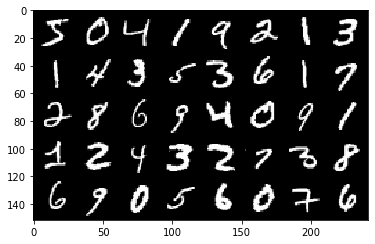

In [ ]:
from torchvision import utils
import matplotlib.pyplot as plt
%matplotlib inline

# Definir una función auxiliar para mostrar tensores como imágenes
def show(img):
    # Convertir el tensor en un arreglo de NumPy
    npimg = img.numpy()
    # Cambiar el orden de las dimensiones a H*W*C (alto, ancho, canales)
    npimg_tr = np.transpose(npimg, (1, 2, 0))
    # Mostrar la imagen utilizando Matplotlib
    plt.imshow(npimg_tr, interpolation='nearest')

# Crear una cuadrícula con 40 imágenes (8 imágenes por fila)
x_grid = utils.make_grid(x_train[:40], nrow=8, padding=2)
print(x_grid.shape)

# Llamar a la función auxiliar para mostrar la cuadrícula de imágenes
show(x_grid)


### Transformación de datos

La **transformación o aumento de imágenes** (*image transformation / augmentation*) es una técnica muy efectiva utilizada para mejorar el rendimiento de un modelo.  

El paquete `torchvision` proporciona transformaciones de imagen comunes a través de la clase `transforms`.


In [ ]:
from torchvision import transforms

# Definir las transformaciones de los datos
data_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),  # Aplica un volteo horizontal con probabilidad 1 (siempre)
    transforms.RandomVerticalFlip(p=1),    # Aplica un volteo vertical con probabilidad 1 (siempre)
    transforms.ToTensor(),                 # Convierte la imagen en un tensor de PyTorch
])


Text(0.5, 1.0, 'transformed')

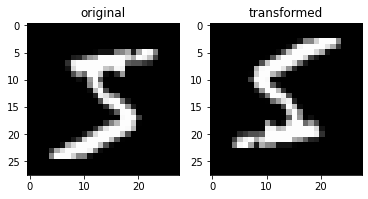

In [ ]:
# Obtener una imagen de muestra del conjunto de entrenamiento
img = train_data[0][0]

# Aplicar las transformaciones definidas a la imagen
img_tr = data_transform(img)

# Convertir el tensor transformado en un arreglo de NumPy
img_tr_np = img_tr.numpy()

# Mostrar la imagen original y la imagen transformada lado a lado
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(img_tr_np[0], cmap="gray")
plt.title("Transformada")


También podemos pasar la función de transformación a la clase del conjunto de datos:


In [ ]:
# Definir las transformaciones de los datos
# data_transform = transforms.Compose([
#     transforms.RandomHorizontalFlip(1),  # Voltea la imagen horizontalmente (siempre)
#     transforms.RandomVerticalFlip(1),    # Voltea la imagen verticalmente (siempre)
#     transforms.ToTensor(),               # Convierte la imagen en un tensor de PyTorch
# ])

# Cargar los datos de entrenamiento de MNIST aplicando las transformaciones en tiempo real (on-the-fly)
# Esto significa que cada vez que se carga una imagen, se aplica la transformación definida.
# train_data = datasets.MNIST(path2data, train=True, download=True, transform=data_transform)


**Crear un conjunto de datos a partir de tensores.**


In [ ]:
from torch.utils.data import TensorDataset

# Envolver los tensores en un conjunto de datos (dataset)
# TensorDataset permite combinar múltiples tensores en un solo objeto de dataset,
# donde cada muestra está compuesta por un par (x, y)
train_ds = TensorDataset(x_train, y_train)
val_ds = TensorDataset(x_val, y_val)

# Mostrar la forma (shape) de una muestra y su etiqueta correspondiente
for x, y in train_ds:
    print(x.shape, y.item())  # x es la imagen, y es la etiqueta (convertida a número con .item())
    break  # Solo mostramos la primera muestra


torch.Size([1, 28, 28]) 5


### Creación de cargadores de datos (*Data Loaders*)

Para iterar fácilmente sobre los datos durante el entrenamiento, podemos crear un **cargador de datos** utilizando la clase `DataLoader`.  
Esta clase permite dividir los datos en *batches* (lotes), barajarlos y cargarlos de forma eficiente durante el proceso de entrenamiento del modelo.


In [ ]:
from torch.utils.data import DataLoader

# Crear un cargador de datos (DataLoader) a partir del conjunto de datos
# batch_size define cuántas muestras se cargarán en cada lote (batch)
train_dl = DataLoader(train_ds, batch_size=8)
val_dl = DataLoader(val_ds, batch_size=8)

# Iterar sobre los lotes del conjunto de entrenamiento
for xb, yb in train_dl:
    print(xb.shape)  # Muestra la forma del lote de imágenes (batch_size, canales, alto, ancho)
    print(yb.shape)  # Muestra la forma del lote de etiquetas (batch_size,)
    break  # Solo mostramos el primer lote


torch.Size([8, 1, 28, 28])
torch.Size([8])


## Construcción de modelos

Un **modelo** es una colección de capas conectadas que procesan las entradas para generar las salidas.  

Podemos utilizar el paquete `nn` de PyTorch para definir modelos. Este paquete contiene una colección de **módulos** que proporcionan las capas más comunes utilizadas en aprendizaje profundo.  

Un módulo o capa de `nn` recibe tensores de entrada, calcula tensores de salida y almacena los pesos (si los tiene).  

En PyTorch, existen dos métodos principales para definir modelos:

1. **`nn.Sequential`** → para crear modelos simples con capas apiladas secuencialmente.  
2. **`nn.Module`** → para crear modelos personalizados o más complejos, definiendo explícitamente el flujo de datos.


Crea una capa lineal y muestra el tamaño de su salida.


In [ ]:
from torch import nn

# Crear un tensor de entrada con dimensiones 64x1000
# (64 muestras y 1000 características por muestra)
input_tensor = torch.randn(64, 1000)

# Definir una capa lineal con 1000 entradas y 10 salidas
# Esta capa aplica una transformación lineal: salida = entrada * W^T + b
linear_layer = nn.Linear(1000, 10)

# Calcular la salida de la capa lineal
output = linear_layer(input_tensor)

# Mostrar el tamaño (shape) del tensor de salida
# Debería ser [64, 10], correspondiente a 64 muestras y 10 salidas por muestra
print(output.size())

torch.Size([64, 10])


In [ ]:
# Implementar y mostrar el modelo utilizando nn.Sequential
from torch import nn

# Definir un modelo de dos capas
# La primera capa lineal recibe 4 entradas y produce 5 salidas
# Luego se aplica la función de activación ReLU
# Finalmente, una segunda capa lineal reduce las 5 salidas a una sola
model = nn.Sequential(
    nn.Linear(4, 5),
    nn.ReLU(),
    nn.Linear(5, 1),
)

# Imprimir la estructura del modelo
print(model)

Sequential(
  (0): Linear(in_features=4, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)


### Definición de modelos utilizando `nn.Module`

Otra forma de definir modelos en PyTorch es **heredando** de la clase `nn.Module`.  

En este enfoque, se especifican las capas del modelo dentro del método `__init__` de la clase.  
Luego, en el método `forward`, se define cómo las entradas pasan a través de las capas para generar la salida.  

Este método ofrece **mayor flexibilidad** y control, lo que resulta ideal para construir modelos personalizados o arquitecturas más complejas.


In [ ]:
import torch.nn.functional as F

# Definición de un modelo de red neuronal personalizada heredando de nn.Module
class Net(nn.Module):
    def __init__(self):
        # Inicializa la clase base nn.Module
        super(Net, self).__init__()
        
        # Primera capa convolucional:
        # - Entrada: 1 canal (por ejemplo, imágenes en escala de grises)
        # - Salida: 20 mapas de características
        # - Tamaño del kernel: 5x5
        # - Stride: 1
        self.conv1 = nn.Conv2d(1, 20, 5, 1)

        # Segunda capa convolucional:
        # - Entrada: 20 canales
        # - Salida: 50 canales
        # - Tamaño del kernel: 5x5
        # - Stride: 1
        self.conv2 = nn.Conv2d(20, 50, 5, 1)

        # Capa completamente conectada (fully connected):
        # - Entrada: 4*4*50 (resultado después de las capas convolucionales y de pooling)
        # - Salida: 500 neuronas
        self.fc1 = nn.Linear(4 * 4 * 50, 500)

        # Capa de salida:
        # - Entrada: 500 neuronas
        # - Salida: 10 neuronas (por ejemplo, 10 clases en MNIST)
        self.fc2 = nn.Linear(500, 10)

    def forward(self, x):
        # Paso hacia adelante (definición del flujo de datos)
        
        # Capa convolucional 1 + ReLU + MaxPooling
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)

        # Capa convolucional 2 + ReLU + MaxPooling
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        # Aplanar la salida para pasarla a las capas completamente conectadas
        x = x.view(-1, 4 * 4 * 50)

        # Capa completamente conectada + ReLU
        x = F.relu(self.fc1(x))

        # Capa de salida + función log_softmax para obtener probabilidades logarítmicas
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Las dos últimas líneas comentadas equivalen a reasignar los métodos manualmente:
# Net.__init__ = __init__
# Net.forward = forward


In [ ]:
# Crear una instancia del modelo definido con la clase Net
model = Net()

# Imprimir la arquitectura del modelo
# Muestra todas las capas y sus configuraciones
print(model)

Net(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)


**Mover el modelo a un dispositivo CUDA (GPU)**


In [ ]:
# Mostrar en qué dispositivo se encuentran actualmente los parámetros del modelo
# Por defecto estarán en la CPU si no se ha movido el modelo a la GPU
print(next(model.parameters()).device)


cpu


In [ ]:
# Definir el dispositivo CUDA (GPU 0)
device = torch.device("cuda:0")

# Mover el modelo a la GPU
model.to(device)

# Verificar que los parámetros del modelo ahora estén en la GPU
print(next(model.parameters()).device)

cuda:0


In [ ]:
# El comando `!pip install torchsummary` se utiliza para instalar el paquete `torchsummary`.
# Este paquete permite ver un resumen de la arquitectura de un modelo de PyTorch,
# incluyendo el número de parámetros, la forma de las salidas de cada capa y el uso de memoria.
!pip install torchsummary

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [ ]:
# Resumen del modelo utilizando torchsummary
from torchsummary import summary

# Mostrar un resumen detallado del modelo:
# - input_size define el tamaño de la entrada (1 canal, 28x28 píxeles)
# El resumen incluye la forma de salida de cada capa, el número de parámetros entrenables
# y la arquitectura general del modelo
summary(model, input_size=(1, 28, 28))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 20, 24, 24]             520
            Conv2d-2             [-1, 50, 8, 8]          25,050
            Linear-3                  [-1, 500]         400,500
            Linear-4                   [-1, 10]           5,010
Total params: 431,080
Trainable params: 431,080
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.12
Params size (MB): 1.64
Estimated Total Size (MB): 1.76
----------------------------------------------------------------


## Función de pérdida y optimizador


**La pérdida de log-verosimilitud negativa (Negative Log-Likelihood Loss, NLLLoss):**


In [ ]:
from torch import nn

# Definir la función de pérdida: Negative Log-Likelihood Loss (NLLLoss)
# reduction="sum" indica que se sumarán las pérdidas de todos los elementos del batch
loss_func = nn.NLLLoss(reduction="sum")


In [ ]:
# Ejemplo de cálculo de la pérdida para un lote de datos
for xb, yb in train_dl:
    # Mover el lote al dispositivo CUDA y asegurar que el tipo sea float
    xb = xb.type(torch.float).to(device)
    yb = yb.to(device)
    
    # Obtener la salida del modelo
    out = model(xb)
    
    # Calcular el valor de la pérdida utilizando NLLLoss
    loss = loss_func(out, yb)
    
    # Imprimir el valor de la pérdida
    print(loss.item())
    break  # Solo se calcula la pérdida para el primer lote


134.22616577148438


In [ ]:
# Definir el optimizador Adam para actualizar los parámetros del modelo
from torch import optim

# lr = 1e-4 define la tasa de aprendizaje
opt = optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
# Actualizar los parámetros del modelo usando el optimizador
# Este paso aplica los gradientes calculados previamente durante la retropropagación (loss.backward())
opt.step()

In [ ]:
# Reiniciar los gradientes de todos los parámetros del modelo a cero
# Esto se hace antes de calcular la retropropagación para evitar acumular gradientes de pasos anteriores
opt.zero_grad()

## Entrenamiento y evaluación


In [ ]:
# Función auxiliar para calcular la pérdida por mini-batch
def loss_batch(loss_func, xb, yb, yb_h, opt=None):
    """
    loss_func : función de pérdida
    xb        : mini-batch de entradas
    yb        : mini-batch de etiquetas verdaderas
    yb_h      : predicciones del modelo
    opt       : optimizador (opcional, si se quiere actualizar el modelo)
    """
    
    # Calcular la pérdida del mini-batch
    loss = loss_func(yb_h, yb)
    
    # Calcular la métrica de rendimiento (por ejemplo, accuracy)
    metric_b = metrics_batch(yb, yb_h)
    
    # Si se pasa un optimizador, actualizar los parámetros del modelo
    if opt is not None:
        loss.backward()  # Retropropagación
        opt.step()       # Actualizar parámetros
        opt.zero_grad()  # Reiniciar gradientes
    
    # Retornar la pérdida y la métrica del mini-batch
    return loss.item(), metric_b


In [ ]:
# Función auxiliar para calcular la exactitud (accuracy) por mini-batch
def metrics_batch(target, output):
    """
    target : etiquetas verdaderas del mini-batch
    output : predicciones del modelo (logits o probabilidades logarítmicas)
    """
    
    # Obtener la clase predicha (la de mayor valor en la salida)
    pred = output.argmax(dim=1, keepdim=True)
    
    # Comparar las predicciones con las etiquetas verdaderas
    corrects = pred.eq(target.view_as(pred)).sum().item()
    
    # Retornar el número de predicciones correctas en el mini-batch
    return corrects


In [ ]:
# helper function to compute the loss and metric values for a dataset
# Función auxiliar para calcular la pérdida y la métrica para todo un dataset
def loss_epoch(model, loss_func, dataset_dl, opt=None):
    """
    model      : modelo de PyTorch
    loss_func  : función de pérdida
    dataset_dl : DataLoader del dataset a evaluar
    opt        : optimizador (opcional, si se desea entrenar)
    """
    loss = 0.0
    metric = 0.0
    len_data = len(dataset_dl.dataset)  # número total de muestras en el dataset
    
    # Iterar sobre los lotes del DataLoader
    for xb, yb in dataset_dl:
        xb = xb.type(torch.float).to(device)  # mover datos al dispositivo CUDA y asegurar tipo float
        yb = yb.to(device)                     # mover etiquetas al dispositivo
        
        # Obtener predicciones del modelo
        yb_h = model(xb)
        
        # Calcular pérdida y métrica del mini-batch
        loss_b, metric_b = loss_batch(loss_func, xb, yb, yb_h, opt)
        
        # Acumular pérdidas y métricas
        loss += loss_b
        if metric_b is not None:
            metric += metric_b
    
    # Promediar la pérdida y la métrica por número de muestras
    loss /= len_data
    metric /= len_data
    
    return loss, metric


In [ ]:
# Función para entrenar y validar el modelo durante varias épocas
def train_val(epochs, model, loss_func, opt, train_dl, val_dl):
    """
    epochs     : número de épocas de entrenamiento
    model      : modelo de PyTorch
    loss_func  : función de pérdida
    opt        : optimizador
    train_dl   : DataLoader del conjunto de entrenamiento
    val_dl     : DataLoader del conjunto de validación
    """
    for epoch in range(epochs):
        # Modo entrenamiento
        model.train()
        train_loss, train_metric = loss_epoch(model, loss_func, train_dl, opt)
  
        # Modo evaluación (desactiva gradientes)
        model.eval()
        with torch.no_grad():
            val_loss, val_metric = loss_epoch(model, loss_func, val_dl)
        
        # Calcular precisión (accuracy) en porcentaje
        accuracy = 100 * val_metric

        # Imprimir resultados de la época
        print("epoch: %d, train loss: %.6f, val loss: %.6f, accuracy: %.2f" %
              (epoch, train_loss, val_loss, accuracy))


In [ ]:
# Ejecutar la función de entrenamiento y validación del modelo
num_epochs = 5  # Número de épocas de entrenamiento
train_val(num_epochs, model, loss_func, opt, train_dl, val_dl)

epoch: 0, train loss: 0.149946, val loss: 0.067528, accuracy: 97.78
epoch: 1, train loss: 0.049187, val loss: 0.055292, accuracy: 98.17
epoch: 2, train loss: 0.027795, val loss: 0.046227, accuracy: 98.73
epoch: 3, train loss: 0.019402, val loss: 0.053462, accuracy: 98.67
epoch: 4, train loss: 0.013972, val loss: 0.039738, accuracy: 98.95


### Guardar y cargar modelos

In [ ]:
# Definir la ruta donde se guardarán los pesos del modelo
weights_path = "weights.pt"

# Guardar los pesos (state_dict) del modelo en un archivo
# state_dict contiene los parámetros del modelo (pesos y biases)
torch.save(model.state_dict(), weights_path)


In [ ]:
# Definir un nuevo modelo (con pesos inicializados aleatoriamente)
_model = Net()

# Cargar los pesos guardados previamente
weights = torch.load(weights_path)
_model.load_state_dict(weights)

# Mover el modelo con los pesos cargados al dispositivo CUDA
_model.to(device)


Net(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)

### Despliegue del modelo

torch.Size([1, 28, 28])


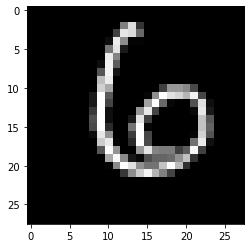

In [ ]:
# Seleccionar una muestra del conjunto de validación para probar el modelo
n = 100
x = x_val[n]  # Imagen de entrada
y = y_val[n]  # Etiqueta verdadera

# Mostrar las dimensiones de la imagen
print(x.shape)

# Visualizar la imagen en escala de grises
plt.imshow(x.numpy()[0], cmap="gray")


In [ ]:
# Expandir las dimensiones de la imagen para que tenga forma [1, C, H, W]
# Esto es necesario porque el modelo espera un batch de imágenes
x = x.unsqueeze(0)

# Convertir la imagen a tipo torch.float32
x = x.type(torch.float)

# Mover la imagen al dispositivo CUDA
x = x.to(device)


In [ ]:
# Obtener la salida del modelo para la imagen de entrada
output = _model(x)

# Obtener la clase predicha (la de mayor valor en la salida)
pred = output.argmax(dim=1, keepdim=True)

# Imprimir la clase predicha y la etiqueta verdadera
print(pred.item(), y.item())

6 6
